# Compiling & Visualizing Tracr Models (with Combined Matrix Values Grid)

This notebook demonstrates how to compile a tracr model and provides tools to visualize the model's residual stream, outputs, and parameters using a combined grid layout instead of many separate figures.

In [1]:
#@title Imports
import jax
import numpy as np
import math
import matplotlib.pyplot as plt

# The default of float16 can lead to discrepancies between outputs of
# the compiled model and the RASP program.
jax.config.update('jax_default_matmul_precision', 'float32')

from tracr.compiler import compiling
from tracr.compiler import lib
from tracr.rasp import rasp

In [2]:
#@title Plotting functions
def tidy_label(label, value_width=5):
  if ':' in label:
    label, value = label.split(':')
  else:
    value = ''
  return label + f":{value:>{value_width}}"

def add_residual_ticks(model, value_width=5, x=False, y=True):
  if y:
    plt.yticks(
            np.arange(len(model.residual_labels))+0.5, 
            [tidy_label(l, value_width=value_width)
              for l in model.residual_labels], 
            family='monospace',
            fontsize=12,
    )
  if x:
    plt.xticks(
            np.arange(len(model.residual_labels))+0.5, 
            [tidy_label(l, value_width=value_width)
              for l in model.residual_labels], 
            family='monospace',
            rotation=90,
            fontsize=12,
    )

def plot_computation_trace_with_values(model,
                                       input_labels,
                                       residuals_or_outputs,
                                       add_input_layer=False,
                                       figsize=(20, 10)):
  fig, axes = plt.subplots(nrows=1, ncols=len(residuals_or_outputs), figsize=figsize, sharey=True)
  value_width = max(map(len, map(str, input_labels))) + 1

  if not isinstance(axes, np.ndarray):
      axes = [axes]

  for i, (layer, ax) in enumerate(zip(residuals_or_outputs, axes)):
    plt.sca(ax)
    matrix = layer[0].T
    
    plt.pcolormesh(matrix, vmin=0, vmax=1, cmap="viridis")
    
    # Annotate numerical values
    for r in range(matrix.shape[0]):
      for c in range(matrix.shape[1]):
        val = matrix[r, c]
        ax.text(c + 0.5, r + 0.5, f"{val:.2f}", color="white" if val < 0.5 else "black", 
                ha="center", va="center", fontsize=9, fontweight='bold')
    
    if i == 0:
      add_residual_ticks(model, value_width=value_width)
      
    plt.xticks(
        np.arange(len(input_labels))+0.5,
        input_labels,
        rotation=90,
        fontsize=14,
    )
    if add_input_layer and i == 0:
      title = 'Input embeddings'
    else:
      layer_no = i - 1 if add_input_layer else i
      layer_type = 'Attn' if layer_no % 2 == 0 else 'MLP'
      title = f'{layer_type} {layer_no // 2 + 1}'
    plt.title(title, fontsize=16)
  plt.tight_layout()

def plot_parameters_grid(model):
  """Plots all parameter matrices in a single figure grid."""
  # Count total number of matrices to determine grid size
  matrices = []
  for param_name, param_value in model.params.items():
    if isinstance(param_value, dict):
      for sub_name, sub_value in param_value.items():
        matrices.append((f"{param_name}/{sub_name}", np.array(sub_value)))
    else:
      matrices.append((param_name, np.array(param_value)))
      
  n = len(matrices)
  cols = 3
  rows = math.ceil(n / cols)
  
  fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
  axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
  
  for i, (title, matrix) in enumerate(matrices):
    ax = axes[i]
    if len(matrix.shape) == 1:
        matrix = np.expand_dims(matrix, axis=0)
    
    cax = ax.matshow(matrix, cmap="viridis")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    
    for r in range(matrix.shape[0]):
      for c in range(matrix.shape[1]):
        val = matrix[r, c]
        ax.text(c, r, f"{val:.2f}", color="white" if val < 0.5 * matrix.max() else "black", 
                ha="center", va="center", fontsize=8, fontweight='bold')
                
    ax.set_title(f"{title} (Shape: {matrix.shape})", pad=20, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    
  # Hide unused subplots
  for j in range(i + 1, len(axes)):
      axes[j].axis('off')
      
  plt.tight_layout()
  plt.show()

In [3]:
#@title Define RASP programs
def get_program(program_name, max_seq_len):
  """Returns RASP program and corresponding token vocabulary."""
  if program_name == "length":
    vocab = {"a", "b", "c", "d"}
    program = lib.make_length()
  elif program_name == "frac_prevs":
    vocab = {"a", "b", "c", "x"}
    program = lib.make_frac_prevs((rasp.tokens == "x").named("is_x"))
  elif program_name == "dyck-2":
    vocab = {"(", ")", "{", "}"}
    program = lib.make_shuffle_dyck(pairs=["()", "{}"])
  else:
    raise NotImplementedError(f"Program {program_name} testing out of scope for default examples.")
  return program, vocab

In [4]:
#@title Assemble model
program_name = "length"  #@param ["length", "frac_prevs", "dyck-2", "dyck-3", "sort", "sort_unique", "hist", "sort_freq", "pair_balance"]
max_seq_len = 5  #@param {label: "Test", type: "integer"}

program, vocab = get_program(program_name=program_name,
                             max_seq_len=max_seq_len)

print(f"Compiling...")
print(f"   Program: {program_name}")
print(f"   Input vocabulary: {vocab}")
print(f"   Context size: {max_seq_len}")

assembled_model = compiling.compile_rasp_to_model(
      program=program,
      vocab=vocab,
      max_seq_len=max_seq_len,
      causal=False,
      compiler_bos="bos",
      compiler_pad="pad",
      mlp_exactness=100)

print("Done.")

Compiling...
   Program: length
   Input vocabulary: {'a', 'b', 'c', 'd'}
   Context size: 5
Done.


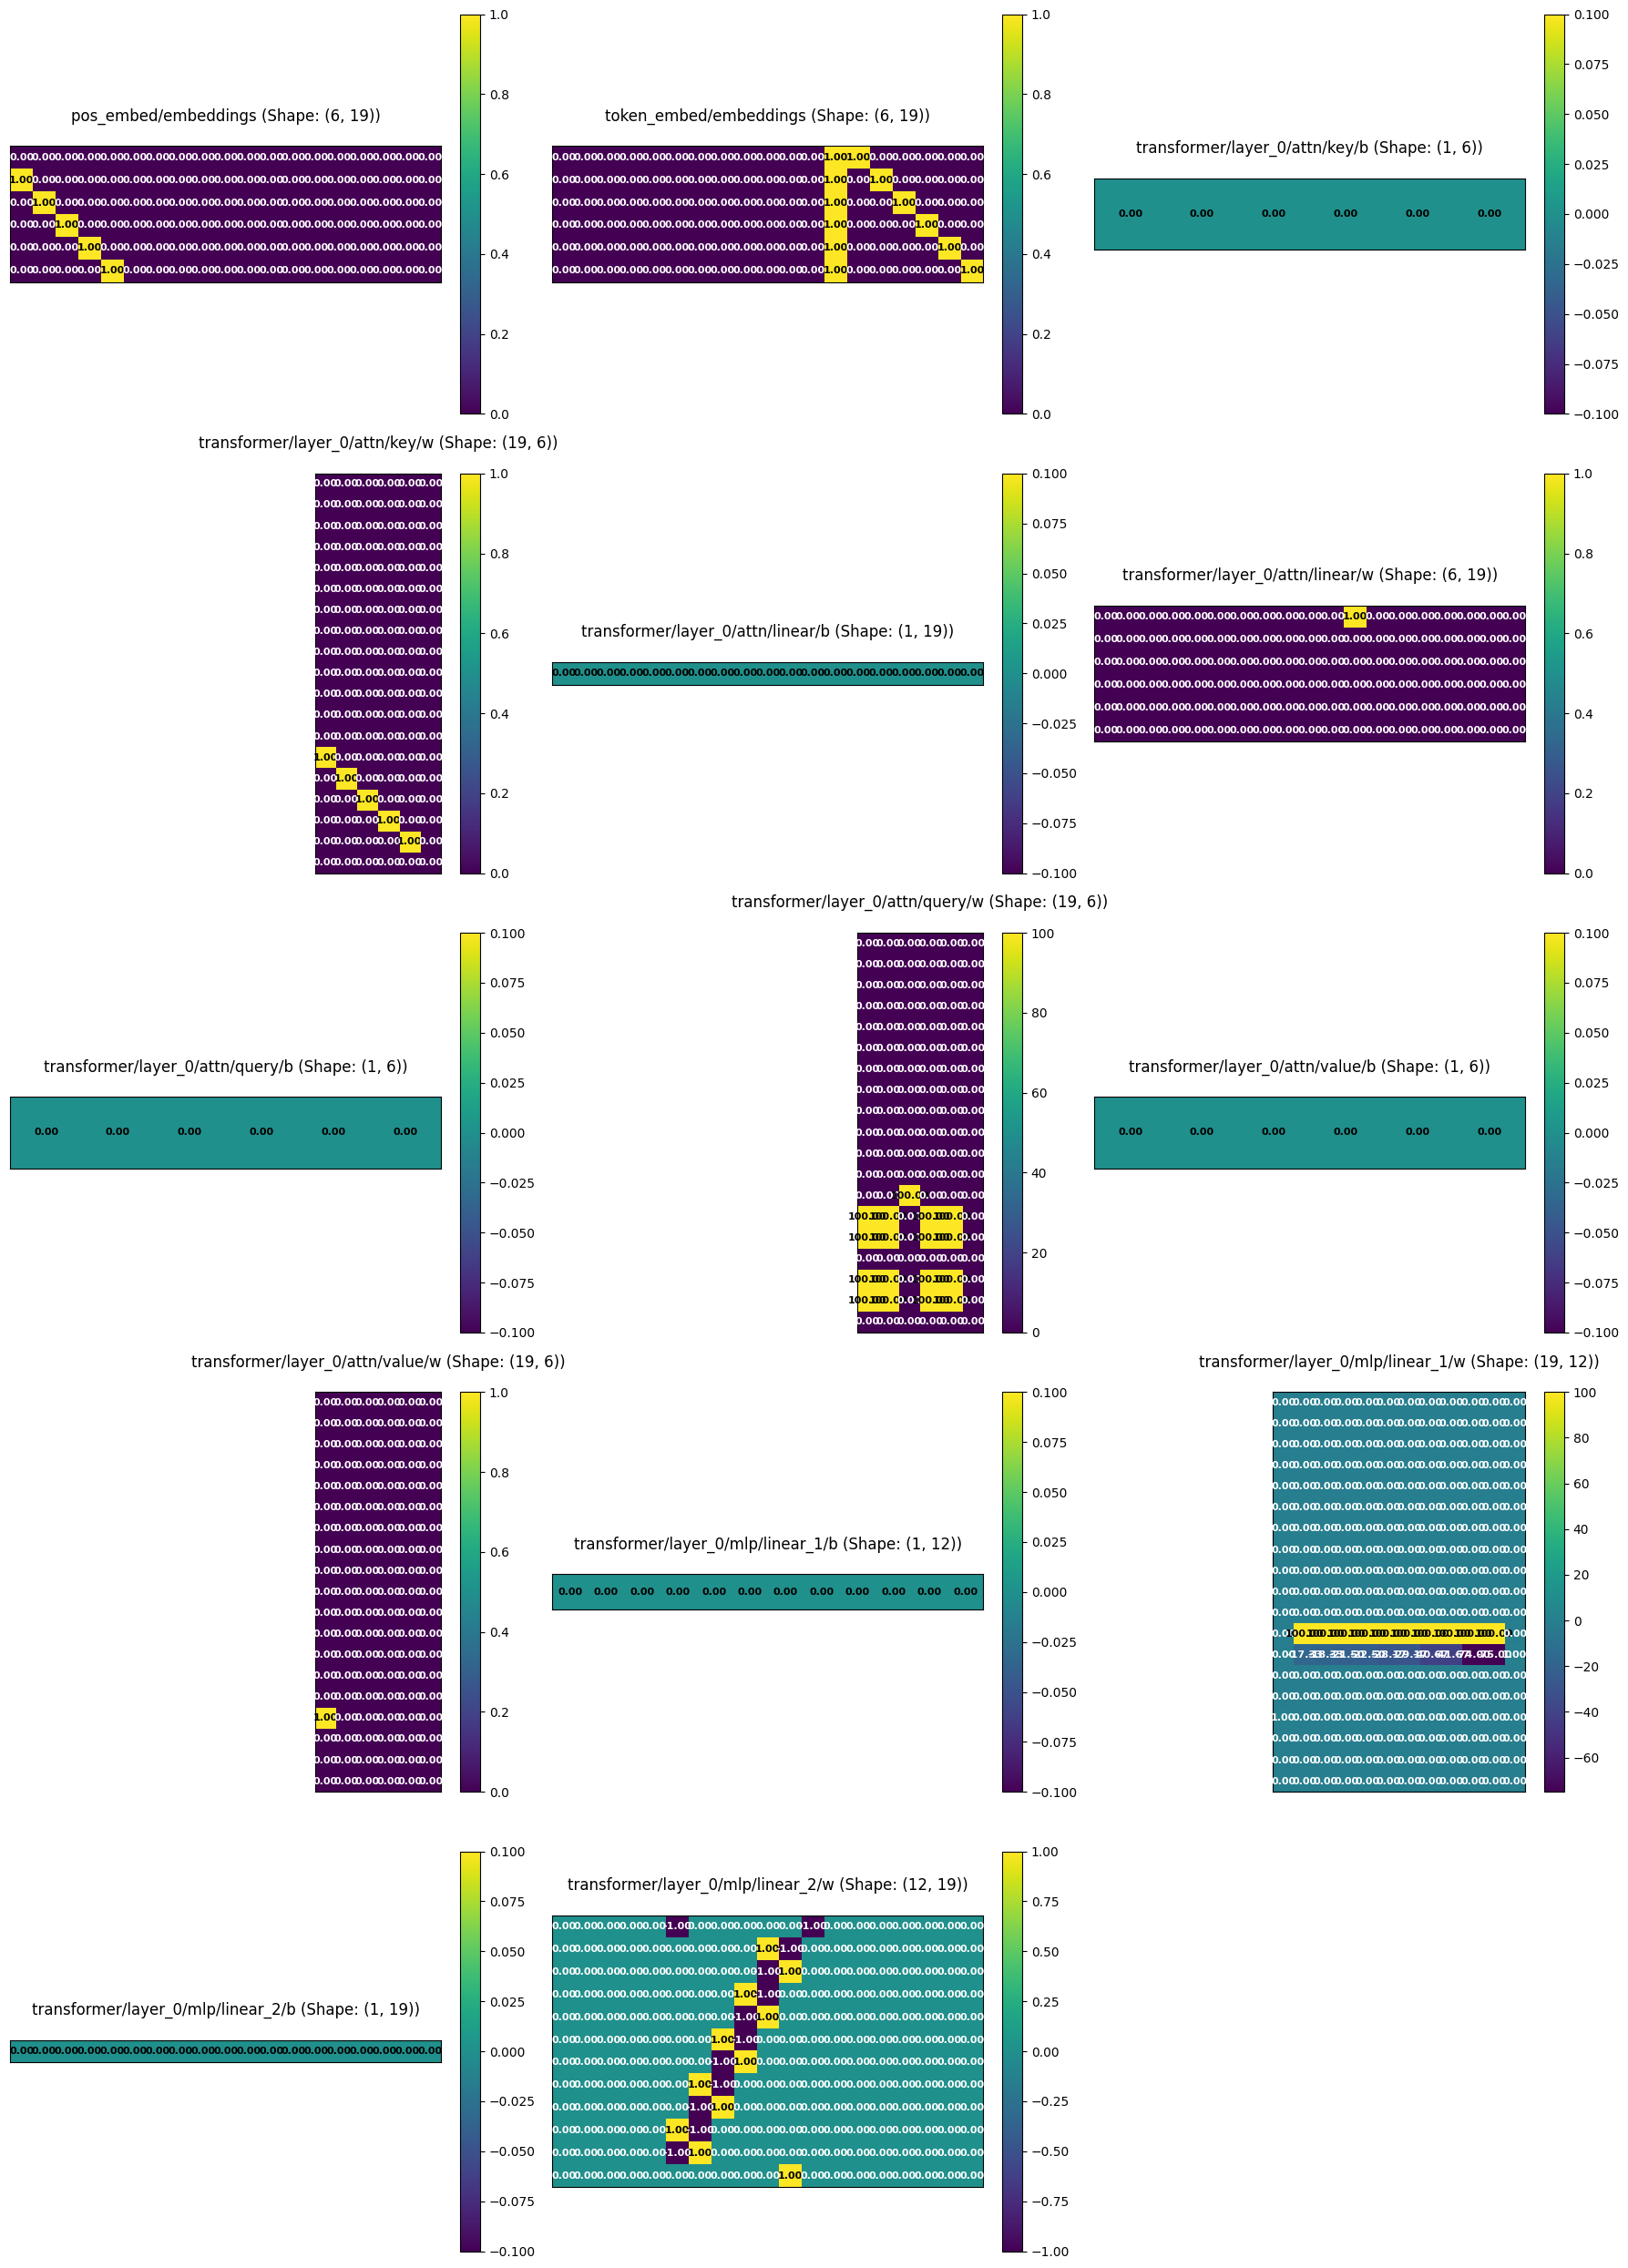

In [5]:
#@title Plot Model Parameters Grid
# This plots all the actual weights inside the compiled transformer in one large grid
plot_parameters_grid(assembled_model)

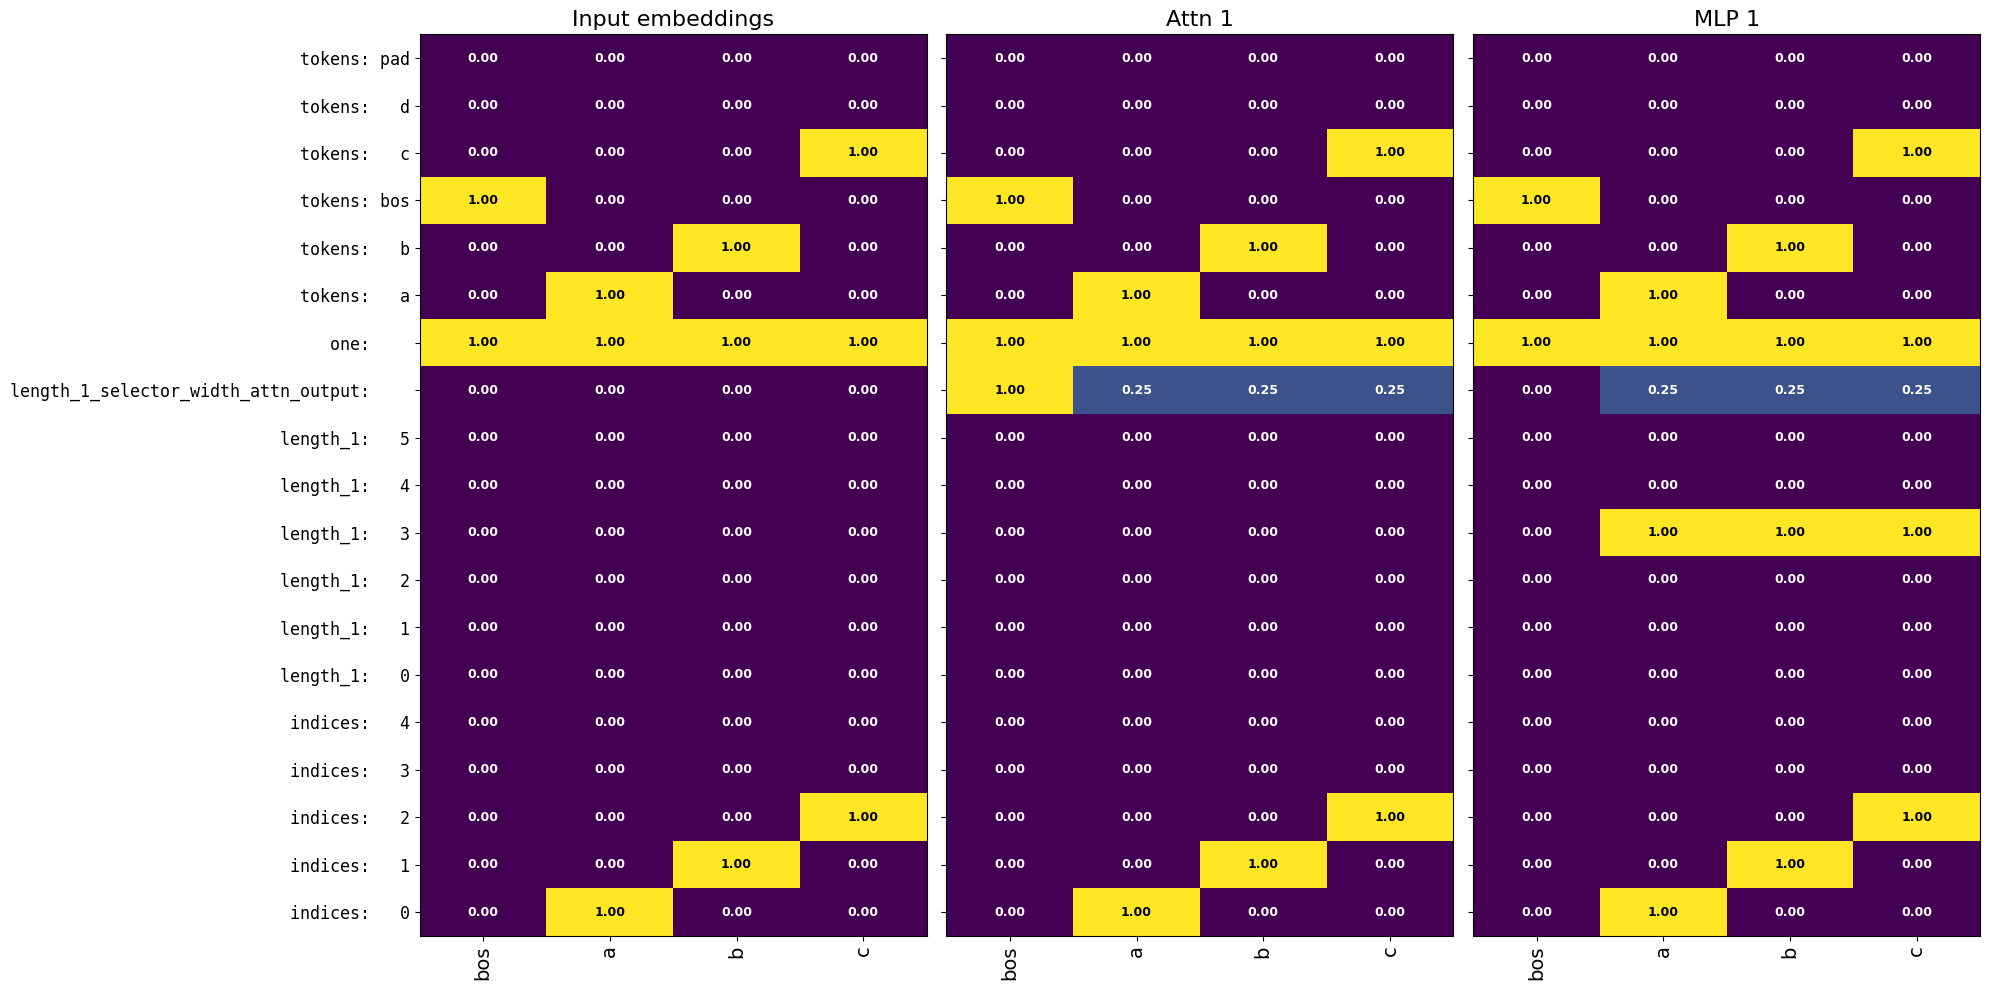

In [12]:
#@title Plot Residual Stream Grid
inputs = ["bos", "a", "b", "c"]

model_out = assembled_model.apply(inputs)
residuals = np.concatenate([model_out.input_embeddings[None, ...],
                            model_out.residuals], axis=0)

plot_computation_trace_with_values(
  model=assembled_model,
  input_labels=inputs,
  residuals_or_outputs=residuals,
  add_input_layer=True,
  figsize=(20, 10)
)

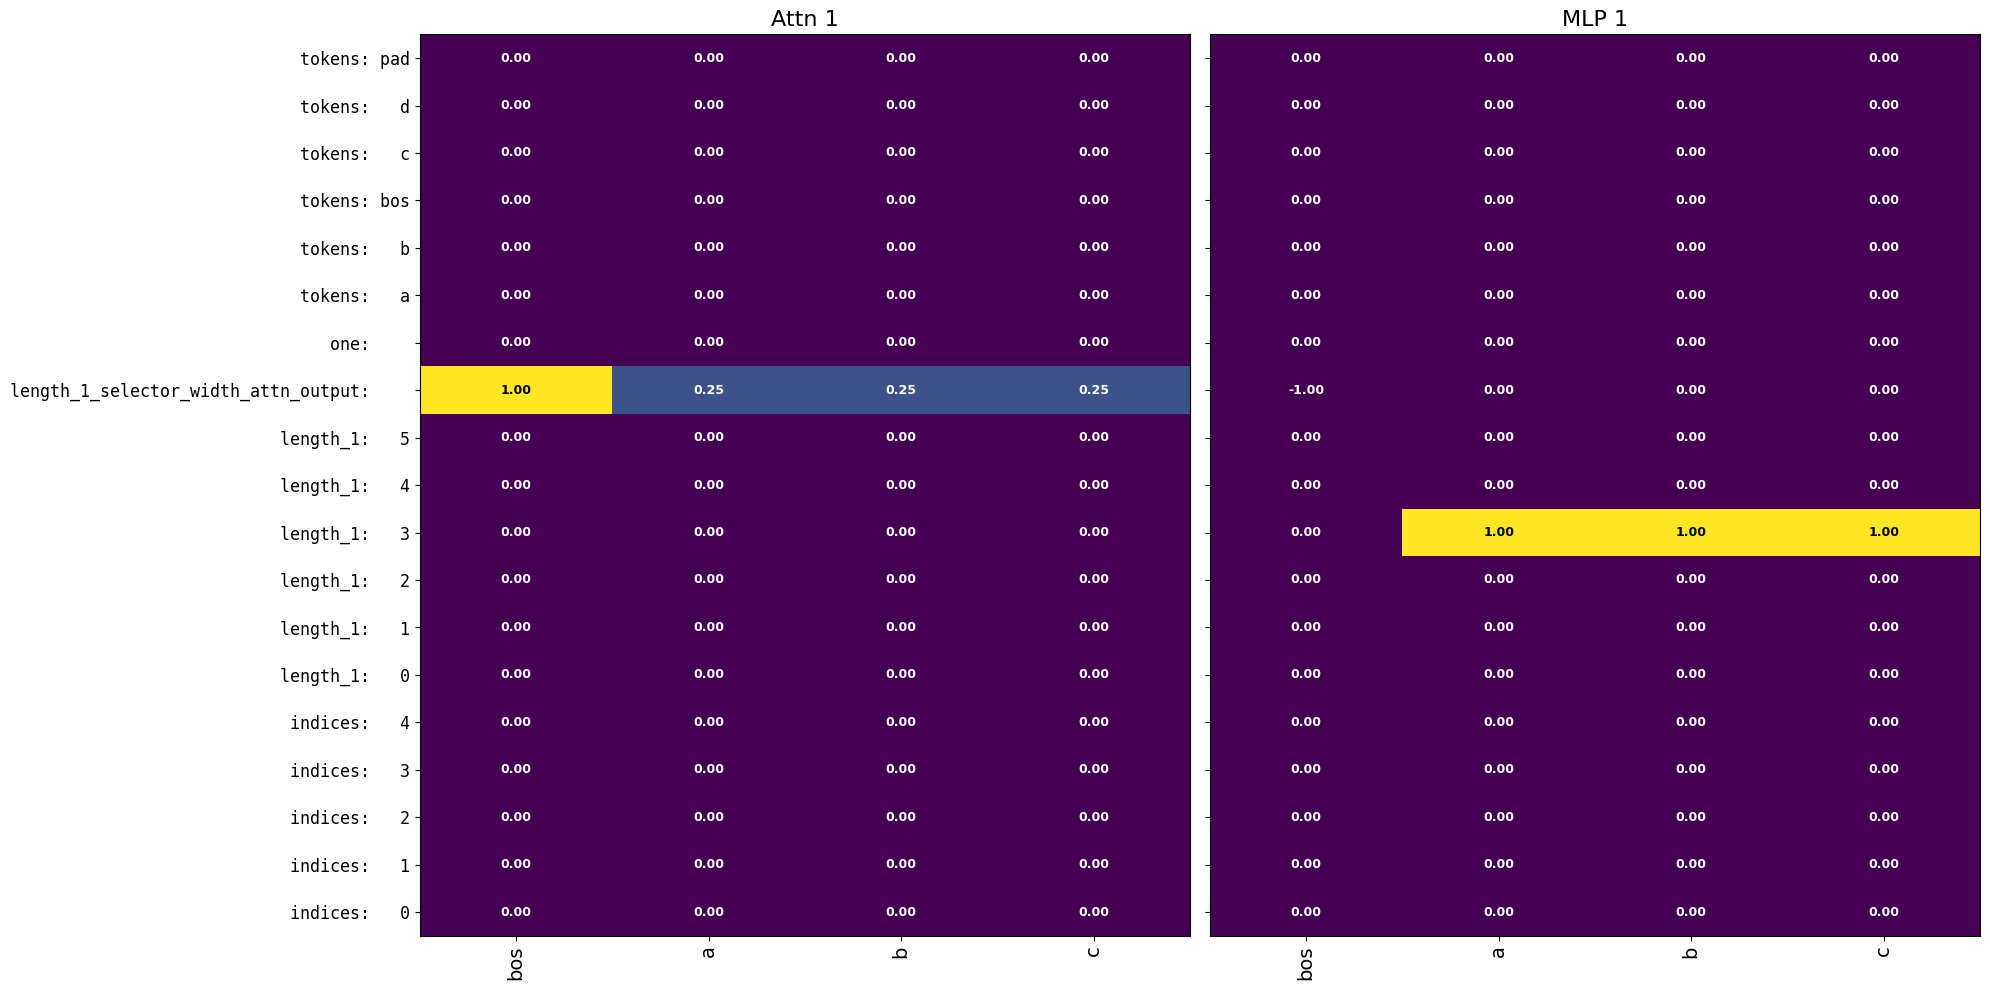

In [13]:
#@title Plot Layer Outputs Grid
plot_computation_trace_with_values(
  model=assembled_model,
  input_labels=inputs,
  residuals_or_outputs=model_out.layer_outputs,
  add_input_layer=False,
  figsize=(20, 10)
)

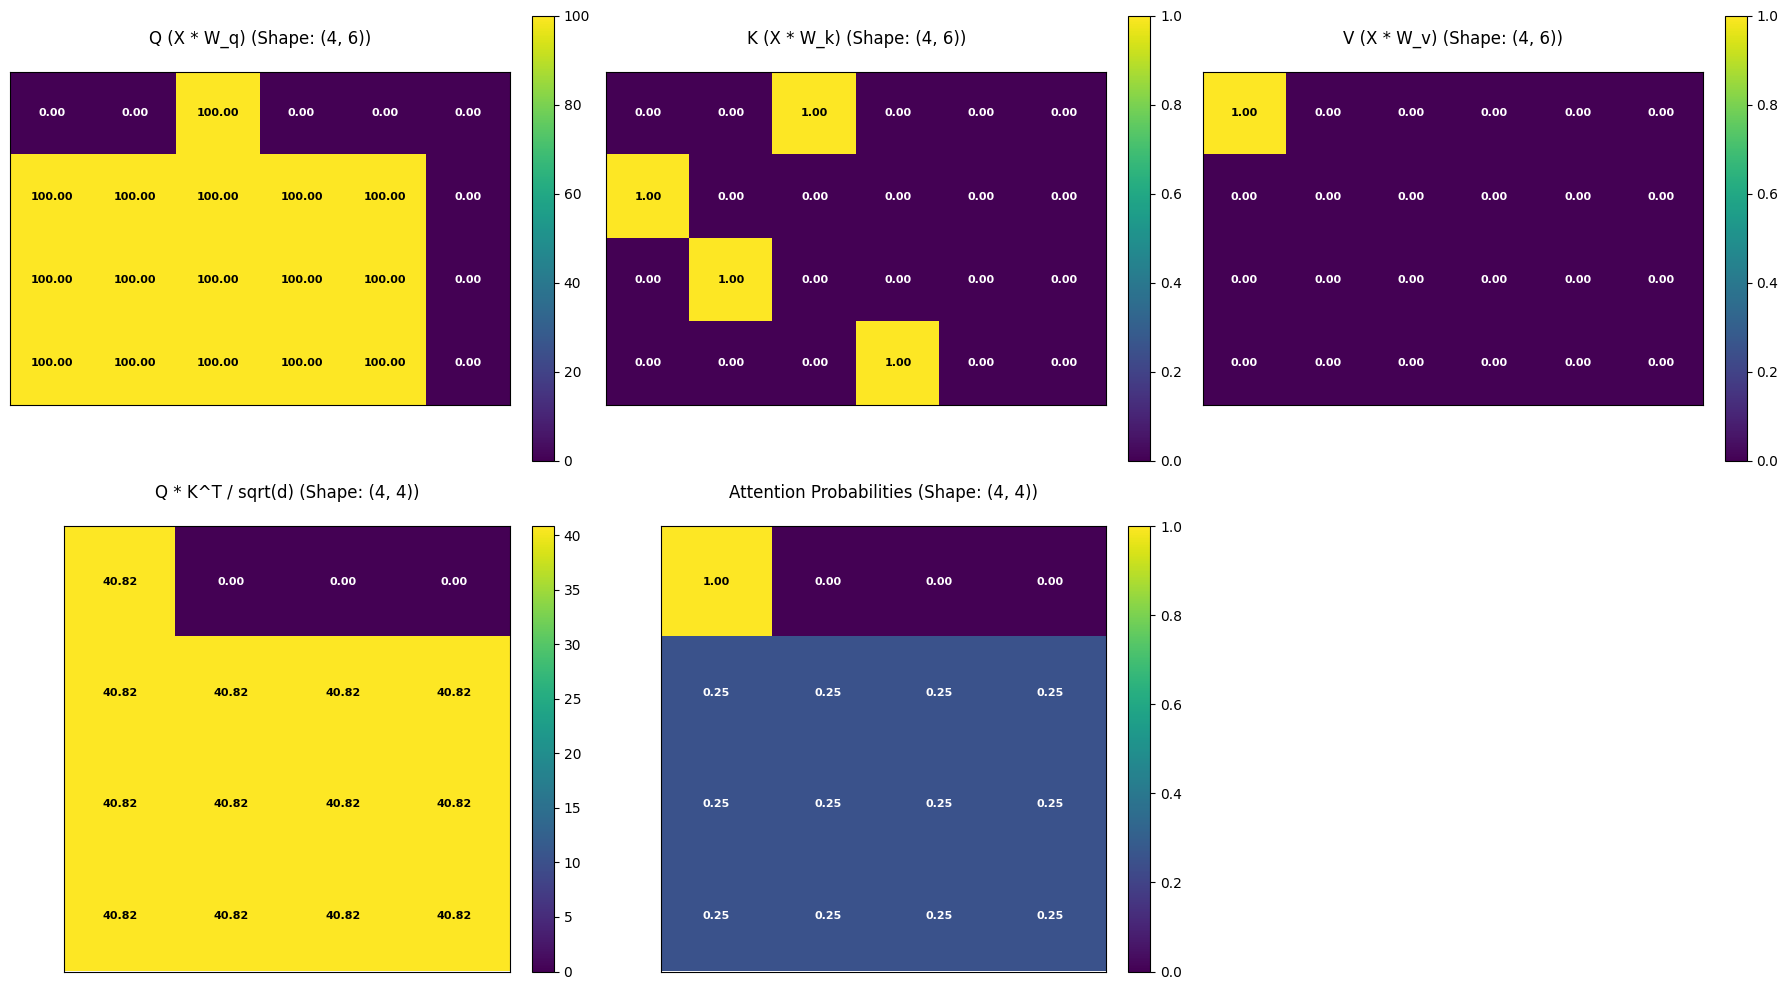

In [14]:
#@title Plot Attention Internals (Q, K, V, etc.)
def plot_attention_internals(model, model_out, layer_idx=0):
    # Get parameters
    q_w = model.params[f'transformer/layer_{layer_idx}/attn/query']['w']
    q_b = model.params[f'transformer/layer_{layer_idx}/attn/query']['b']
    k_w = model.params[f'transformer/layer_{layer_idx}/attn/key']['w']
    k_b = model.params[f'transformer/layer_{layer_idx}/attn/key']['b']
    v_w = model.params[f'transformer/layer_{layer_idx}/attn/value']['w']
    v_b = model.params[f'transformer/layer_{layer_idx}/attn/value']['b']

    # The input to layer i is the residual at layer_idx * 2 (or input embeddings if layer_idx=0)
    if layer_idx == 0:
        X = model_out.input_embeddings[0] # Shape: (seq_len, d_model)
    else:
        X = model_out.residuals[layer_idx * 2 - 1][0] # 

    # Multiply
    Q = X @ q_w + q_b
    K = X @ k_w + k_b
    V = X @ v_w + v_b
    
    # Q K^T
    d_k = q_w.shape[1]
    QK_T = (Q @ K.T) / math.sqrt(d_k)
    
    # Softmax (Attention Weights)
    # subtracting max for numerical stability
    exp_QK_T = np.exp(QK_T - np.max(QK_T, axis=-1, keepdims=True))
    # mask padding/causal if needed? assembled_model is non-causal here
    A = exp_QK_T / np.sum(exp_QK_T, axis=-1, keepdims=True)

    matrices = [
        ('Q (X * W_q)', Q),
        ('K (X * W_k)', K),
        ('V (X * W_v)', V),
        ('Q * K^T / sqrt(d)', QK_T),
        ('Attention Probabilities', A)
    ]
    
    cols = 3
    rows = math.ceil(len(matrices) / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = axes.flatten()
    
    for i, (title, matrix) in enumerate(matrices):
        ax = axes[i]
        cax = ax.matshow(matrix, cmap="viridis")
        fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
        
        for r in range(matrix.shape[0]):
            for c in range(matrix.shape[1]):
                val = matrix[r, c]
                color = "white" if val < 0.5 * matrix.max() else "black"
                ax.text(c, r, f"{val:.2f}", color=color, ha="center", va="center", fontsize=8, fontweight='bold')
                    
        ax.set_title(f"{title} (Shape: {matrix.shape})", pad=20, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        
    for j in range(len(matrices), len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_attention_internals(assembled_model, model_out, layer_idx=0)